# Kmeans, an Unsupervised Learning Technique

Kmeans is a learning technique that splits existing data sets into an arbitrary amount of subgroups. If there are $N$ distinct groups, then each subgroup $S$ has the defining property that for all $P \in S$, there exists a central point $C_i$, where $1 \le i \le n$ (these are called centroids), such that $\|P-C_i\| \le \epsilon$. In other words, each Kmeans subgroup is defined by a unique neighborhood about their corresponding centroids.

We are using Kmeans to determine if there is any significant difference in model performance across different subgroups of our data.

In [2]:
# Unsupervised beginning implementation
from k_means_constrained import KMeansConstrained as KMeans
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

df_slme = joblib.load("Df_slme.pkl")
df_slme_regressor = joblib.load("DTreeRegressor.pkl")

# Forces every element of df_cluster to be numeric
df_cluster= df_slme.select_dtypes(include = ["number"])
#Kmeans Implemented for seven clusters, or groups
num_points = df_cluster.shape[0]
optim_size = num_points//7
kmeans = KMeans(n_clusters = 7, size_min = optim_size , random_state = 42,  n_init = 50)
kmeans.fit_transform(df_cluster)
labels = kmeans.labels_
df_slme["labels"] = labels




# Seven Kmeans Clusters
labels_df = pd.DataFrame({"formula":df_slme["formula"], "label": df_slme["labels"]})

print(labels_df)
# Creates a list of Clusters for ease of accessibility 
df_cluster_list = [df_slme[df_slme["labels"] == i] for i in range(0,7)]

for df_cluster in df_cluster_list:
    print(df_cluster)
    print("\n")



c:\Users\nitro\AppData\Local\Programs\Python\Python313\Lib\site-packages\k_means_constrained\k_means_constrained_.py:464: RuntimeWarning: invalid value encountered in cast
  costs = np.around(costs * 1000, 0).astype('int32')  # Times by 1000 to give extra precision


        formula  label
20     PdSe8Cl2      5
23       LiSbF6      3
24         AlAs      3
25         SrB6      3
26          SiS      3
...         ...    ...
75345     Li4HN      6
75566    PmCdGa      6
75593    HfInAu      6
75961    HfPdPb      6
75972  NaMg2Sb2      6

[9770 rows x 2 columns]
      spg_number spg_symbol    formula  formation_energy_peratom       func  \
33151         59       Pmmn      TeMoS                  -0.57919  OptB88vdW   
33153        139     I4/mmm    Bi2SeO2                  -1.10048  OptB88vdW   
33158        227      Fd-3m    Cd2SiO4                  -1.85174  OptB88vdW   
33177        180     P6_222       SiO2                  -2.88415  OptB88vdW   
33187         12       C2/m  TbBa2BiO6                  -2.64133  OptB88vdW   
...          ...        ...        ...                       ...        ...   
40259        121      I-42m     K3TaO8                  -1.61258  OptB88vdW   
40263         15       C2/c  SrH4Cl2O2                  -1.56731  O

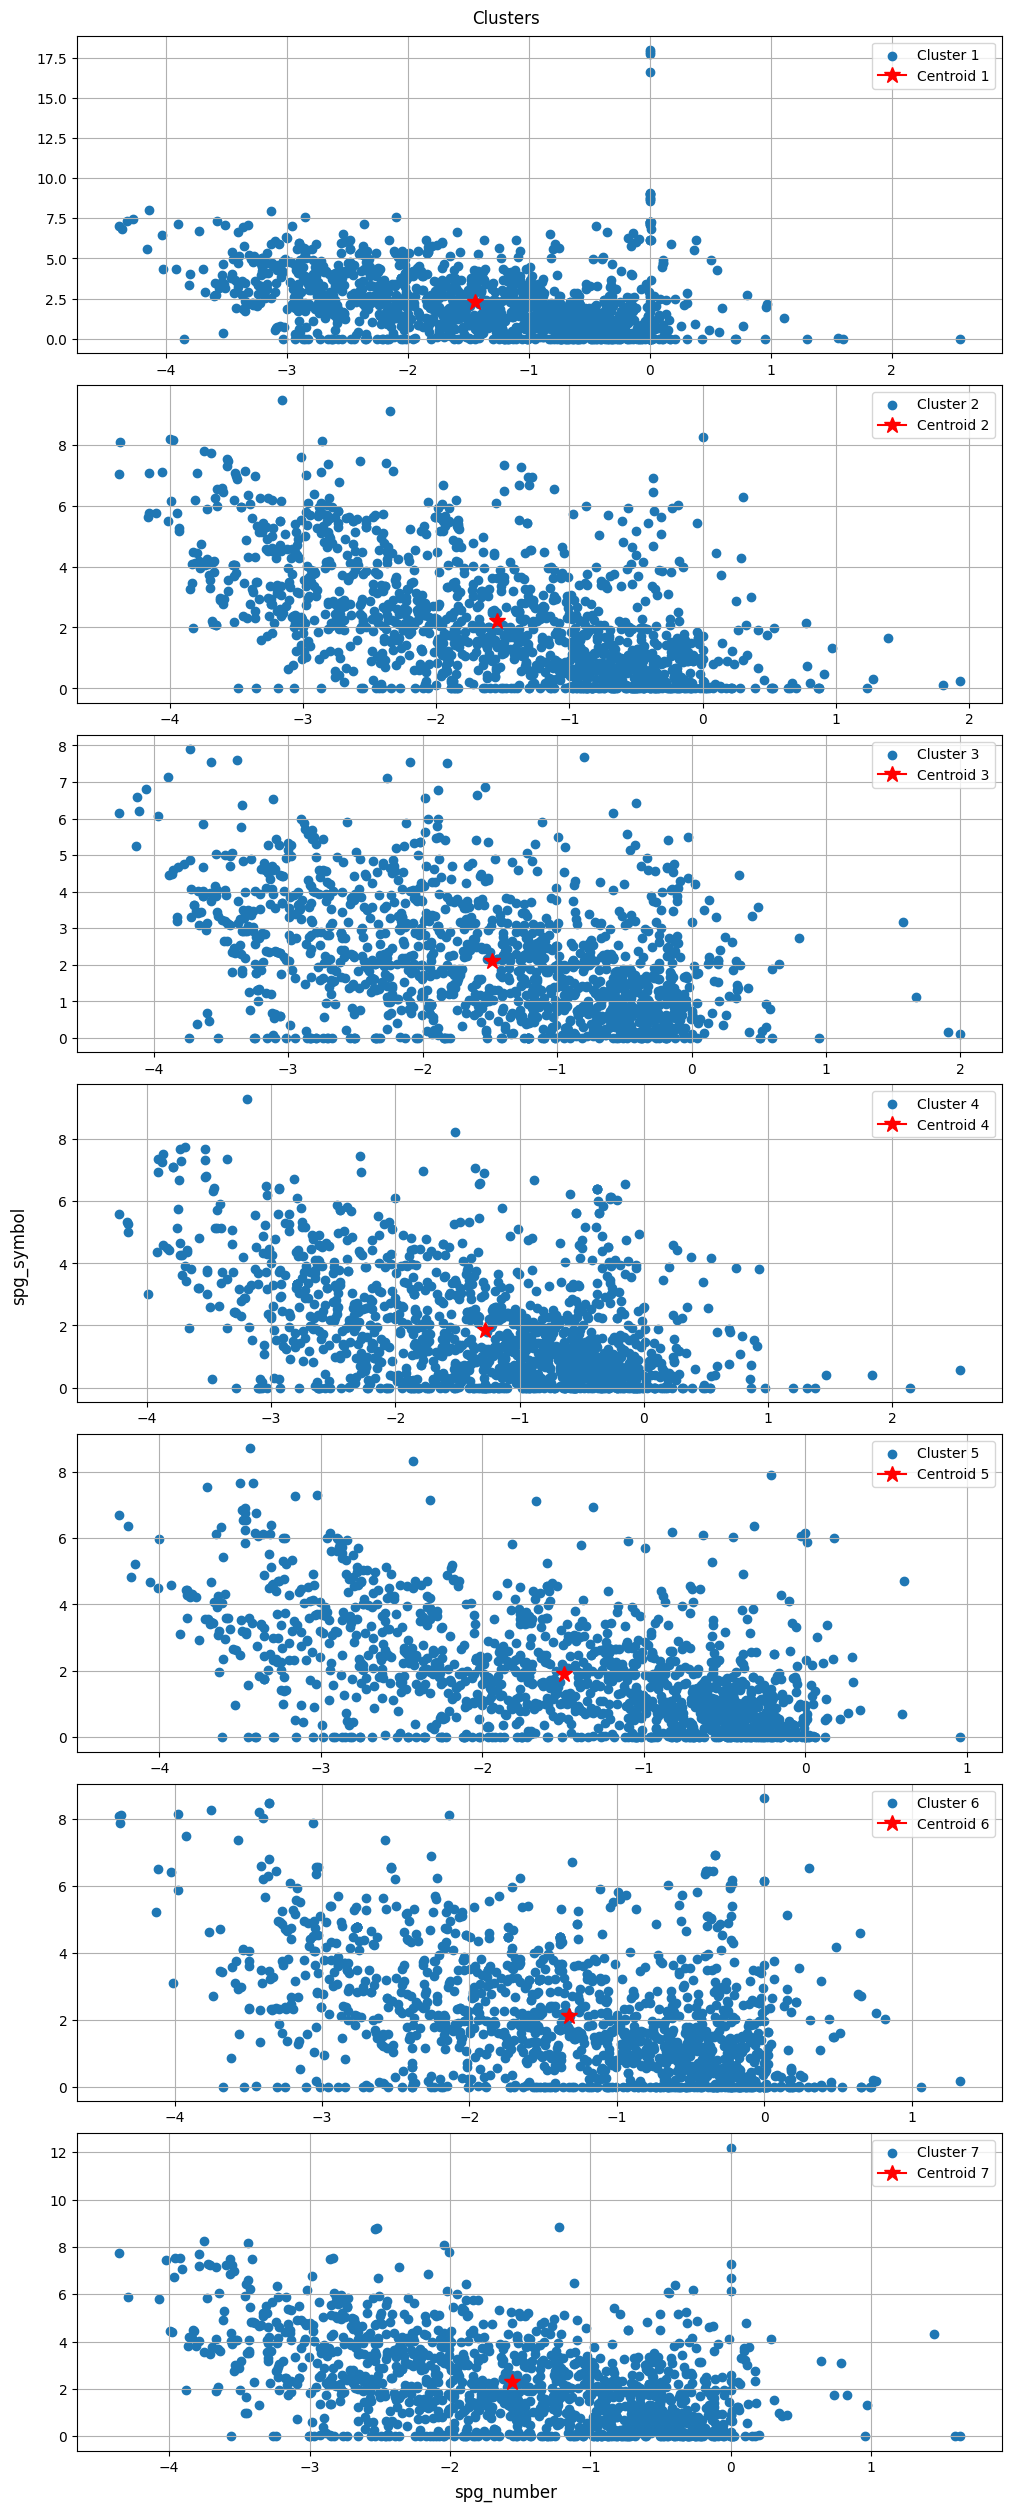

In [3]:


#Plotting each Cluster with the Centroid Clearly Shown
fig,axs = plt.subplots(nrows = 7, ncols = 1,constrained_layout = True)
centroids_X = kmeans.cluster_centers_[:,0]
centroids_Y = kmeans.cluster_centers_[:,1]  
fig.set_size_inches(10, 25)
fig.supxlabel(df_cluster.columns[0])
fig.supylabel(df_cluster.columns[1])
fig.suptitle("Clusters")


for i in range(len(axs)):
    cluster = df_cluster_list[i]
    scatter_i = axs[i].scatter(cluster.select_dtypes(include = ["number"]).iloc[:,0],
                      cluster.select_dtypes(include = ["number"]).iloc[:,1],
                      label = f"Cluster {i+1}")
    centroid_i = axs[i].plot(centroids_X[i],centroids_Y[i], marker = "*", color = "red", markersize = 12, label = f"Centroid {i+1}")
    axs[i].grid()
    axs[i].legend()
    






In [4]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,accuracy_score, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
import random

def train_cluster(df_cluster):
    """
    Prints 
    """
    
    
    X = df_cluster.select_dtypes(include = ["number"]).drop(columns = ["slme", "slme_10","labels"])
    Y = df_cluster["slme_10"]
    rand = random.randint(1,100)
    X_train,X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, random_state = rand)
    
    indices = Y_test.index
    
    df_slme_regressor.fit(X_train,Y_train)
    
    Y_pred = df_slme_regressor.predict(X_test)


    result = pd.DataFrame({"formula": df_cluster.loc[indices,"formula"], "Actual": Y_test, "Predicted": (Y_pred>0.5).astype(int)})
    result.index = [i+1 for i in range(0,len(result))]
    num_materials = len(result)
    num_suitable_materials = result["Predicted"].sum(axis = 0)
    accuracy = accuracy_score(result["Actual"],result["Predicted"])
    

    return result, num_materials, num_suitable_materials, accuracy, 

# Training Results for each cluster 
for i in range(len(df_cluster_list)):
    cluster = df_cluster_list[i]
    result, num_materials, num_suitable_materials, accuracy = train_cluster(cluster)
    df_cluster_list[i] = result
    print (f"======== Cluster {i} results ========")
    print(result, "\n\n")
    print("Number of total materials:", len(result))
    print("Number of Predicted suitable materials: ", num_suitable_materials)
    print("Number of Acutal suitable materials: ",result["Actual"].sum(axis = 0) )
    print("Accuracy", accuracy, "\n")
    

# Obtaining the materials from the dataF


concated_suitable_vals = pd.concat([ cluster[cluster["Predicted"] == 1]["formula"] for cluster in df_cluster_list], axis = 0)
concated_suitable_vals.to_csv("Predicted_vals.csv")
print(concated_suitable_vals)







======== Cluster 0 results ========
       formula  Actual  Predicted
1       TiPCl9       1          1
2     Ho2CdSe4       1          1
3        SiH3F       0          0
4      Mn3O2F2       0          0
5       Li5SbS       1          1
..         ...     ...        ...
276      ScBrO       0          0
277     BiSbO4       0          0
278    Li2MnF6       1          1
279    ZnSb2O4       0          0
280  LiTl2InF6       1          1

[280 rows x 3 columns] 


Number of total materials: 280
Number of Predicted suitable materials:  101
Number of Acutal suitable materials:  99
Accuracy 0.9857142857142858 

======== Cluster 1 results ========
       formula  Actual  Predicted
1         SbO2       1          1
2        MgWF5       0          0
3          CSO       0          0
4       HfZrO4       0          0
5     BaZrP2O8       0          0
..         ...     ...        ...
275     Sr3SbN       0          0
276  Te4Mo3Se2       0          0
277        PrN       0          0
278   

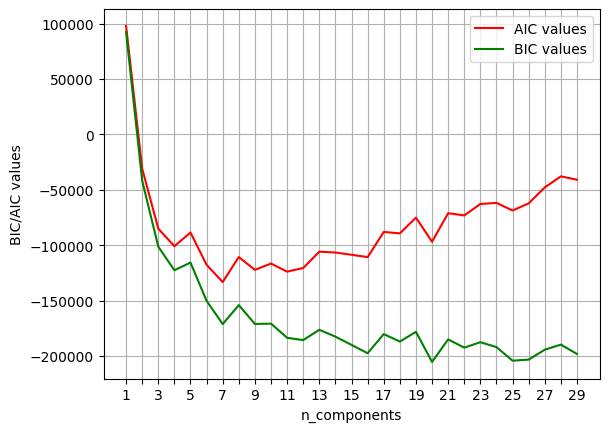

optim_cluster_AIC: 7

optim_cluster_BIC: 7 

optim_cluster_line: 1 

Optimal GMM model number of components: 7 



C:\Users\nitro\AppData\Local\Temp\ipykernel_28728\688611011.py:52: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  optim_clusters_AIC = np.argmax(np.abs(np.cross(points_AIC-P1_AIC,Pn_AIC-P1_AIC))
C:\Users\nitro\AppData\Local\Temp\ipykernel_28728\688611011.py:60: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  optim_clusters_BIC = np.argmax(np.abs(np.cross(points_BIC-P1_BIC,Pn_BIC-P1_BIC))


In [5]:
from sklearn.mixture import GaussianMixture as GMM
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

GMM_models = [GMM(n_components = i, covariance_type = "full", random_state = 42, n_init = 10, reg_covar = 1e-6) for i in range(1,30)]
AIC_VALS = []
BIC_VALS = []
df_numerical = df_cluster.select_dtypes(include = ["number"]).drop(columns = ["slme", "slme_10","labels"])

scaler = StandardScaler()
mean_Scaler = SimpleImputer()
df_final_transform = mean_Scaler.fit_transform(df_numerical)
df_numerical_standard = scaler.fit_transform(df_final_transform)
pca = PCA(n_components = 30)
data_nd = pca.fit(df_numerical_standard)
optim_components = np.searchsorted(pca.explained_variance_ratio_.cumsum(),0.9)+1
pca = PCA(n_components = optim_components)
data_nd  = pca.fit_transform(df_numerical_standard)
df_nd = pd.DataFrame(data_nd, columns = [f"PCA{i}" for i in range(0,data_nd.shape[1])])



for gmm_model in GMM_models:
    gmm_model.fit(df_numerical_standard)
    BIC_VALS.append(gmm_model.aic(df_numerical_standard))  
    AIC_VALS.append(gmm_model.bic(df_numerical_standard))


X_constraints = np.arange(1,len(GMM_models)+1)
plt.plot(X_constraints, AIC_VALS, label = "AIC values", color = "r", linestyle = "-"  )
plt.plot(X_constraints, BIC_VALS , label = "BIC values", color =  "g", linestyle = "-")
plt.ylabel("BIC/AIC values")
plt.xlabel("n_components")
plt.xticks(X_constraints, labels = [str(i) if i%2 == 1 else "" for i in range(1, 30)])
plt.legend()
plt.grid(visible = "true")
plt.show()


np_AIC = np.array(AIC_VALS, dtype = float)
np_BIC = np.array(BIC_VALS , dtype = float)

np_AIC = (np_AIC - np_AIC.min())/(np_AIC.max() - np_AIC.min())
np_BIC = (np_BIC - np_BIC.min())/(np_BIC.max() - np_BIC.min())
cluster_num_normalized = np.linspace(0,1,29)

points_AIC = np.array([(cluster_num_normalized[i], np_AIC[i]) for i in range(0,len(np_AIC))], dtype = float)
P1_AIC = points_AIC[0]
Pn_AIC = points_AIC[-1]

optim_clusters_AIC = np.argmax(np.abs(np.cross(points_AIC-P1_AIC,Pn_AIC-P1_AIC))
                                  /np.linalg.norm(Pn_AIC-P1_AIC))+1

points_BIC = np.column_stack((cluster_num_normalized, np_BIC))

P1_BIC = points_BIC[0]
Pn_BIC = points_BIC[-1]

optim_clusters_BIC = np.argmax(np.abs(np.cross(points_BIC-P1_BIC,Pn_BIC-P1_BIC))
                                  /np.linalg.norm(Pn_BIC-P1_BIC))+1


#AIC_first_deriv = np_AIC[1:]-np_AIC[0:-1]
#BIC_first_deriv = np_BIC[1:]-np_BIC[0:-1] 

optim_cluster_number = np.argmax(np.abs(np_AIC-cluster_num_normalized))+1



print(f"optim_cluster_AIC: {optim_clusters_AIC}\n")
print(f"optim_cluster_BIC: {optim_clusters_BIC} \n")
print(f"optim_cluster_line: {optim_cluster_number} \n")

optim_cluster_num = min(optim_clusters_AIC,optim_clusters_BIC)

optim_GMM_model  = GMM(n_components = optim_cluster_num, covariance_type = "full", random_state = 42, n_init = 10)

print(f"Optimal GMM model number of components: {optim_cluster_num} \n")














(44, 44) (44, 44)
(44, 44) (44, 44)
(44, 44) (44, 44)
(44, 44) (44, 44)
(44, 44) (44, 44)
(44, 44) (44, 44)
(44, 44) (44, 44)


C:\Users\nitro\AppData\Local\Temp\ipykernel_28728\2824366023.py:56: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  axs[i//2][i%2].plot(ellipse[0,:],ellipse[1,:],'r', color = colors[i], alpha = 0.5)


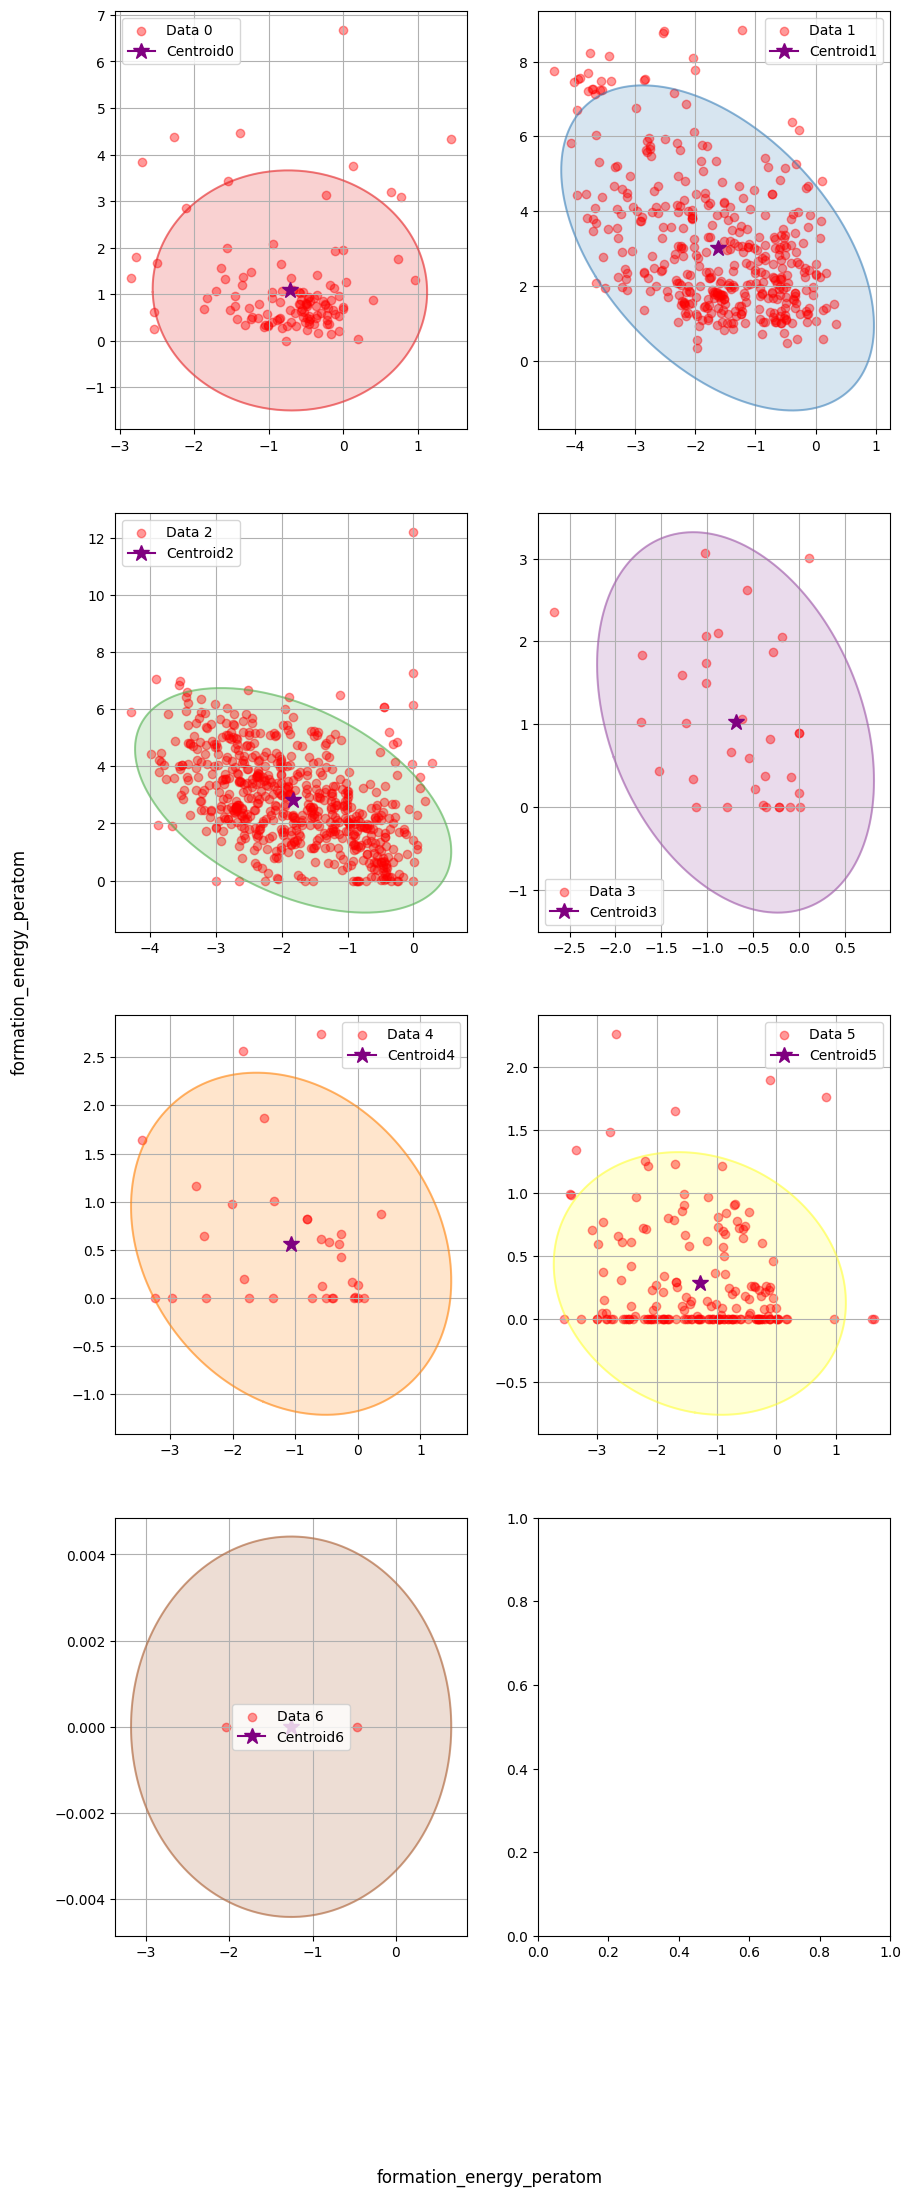

In [20]:
#Once we have determined the optimal GMM_model to use, we follow similar pipline for kmeans
#Split data into clusters based on GMM_model
#plot results using fig, ax and continue

from sklearn.decomposition import PCA
from scipy import linalg




optim_GMM_model.fit(df_numerical_standard)
optim_GMM_means = optim_GMM_model.means_
optim_GMM_labels = optim_GMM_model.predict(df_numerical_standard)
optim_GMM_covariances = optim_GMM_model.covariances_
df_numerical["labels"] = optim_GMM_labels
grouped_values = df_numerical.groupby("labels")

#cluster_list = [df_numerical.[optim_GMM_labels = i ,] for i in range()
#df_labels = pd.dataframe({"formula": df_numerical["formula"], "slme_10": df_slme["slme"], "optim_GMM_labels":})


fig,axs = plt.subplots(nrows = 4, ncols = 2)
fig.set_size_inches(10, 25)
fig.supxlabel(df_numerical.columns[0])
fig.supylabel(df_numerical.columns[0])

scale_matrix = np.vstack([scaler.scale_[i] * scaler.scale_ for i in range(len(scaler.scale_))])
colors = ["#e41a1c",  # red
          "#377eb8",  # blue
          "#4daf4a",  # green
          "#984ea3",  # purple
          "#ff7f00",  # orange
          "#ffff33",  # yellow
          "#a65628"]  
#scaled_covariance = optim_GMM_covariances @ scale_matrix
#scaled_means =  optim_GMM_means @ np.diag(scaler.scale_) + scaler.mean_



for i, (mean, covariance, (label,cluster)) in enumerate(zip(optim_GMM_means, optim_GMM_covariances, grouped_values)):
    """
    Implement tomorrow I guessn

    
    """
    print(covariance.shape,scale_matrix.shape)
    scaled_covaraince = covariance * scale_matrix
    angle_param = np.linspace(0,2*np.pi,360)
    rotation_vec = np.vstack((np.cos(angle_param),np.sin(angle_param)))
    eigen_val, eigen_vector = linalg.eigh(scaled_covaraince[0:2,0:2])
    scaled_mean = mean @ np.diag(scaler.scale_)+scaler.mean_
    ellipse = scaled_mean[:,np.newaxis][0:2,:] + eigen_vector @ np.diag(eigen_val**0.5*np.sqrt(5.992)) @ rotation_vec    
    #ellipse = scaler.inverse_transform(ellipse[0:1,:])
    axs[i//2][i%2].fill(ellipse[0,:], ellipse[1,:],
                         color=colors[i], alpha=0.2)
    axs[i//2][i%2].plot(ellipse[0,:],ellipse[1,:],'r', color = colors[i], alpha = 0.5)
    axs[i//2][i%2].scatter(cluster.values[:,0],cluster.values[:,1],alpha = 0.4, color = "red", label = f"Data {i}" )
    axs[i//2][i%2].plot(scaled_mean[0],scaled_mean[1],color = "purple",marker = "*",markersize = 12, label = f"Centroid{i}")
    axs[i//2][i%2].grid()
    axs[i//2][i%2].legend()

    #axs[i//2][i%2].set_aspect('equal', adjustable='datalim')
    
    
     # Project mean to 2D (first two features)

    

    
    

    
   

   



#GMM_clusters = 



